# ⚙️ Data Preprocessing — AI4I 2020 Predictive Maintenance

This notebook covers all preprocessing steps required before training a **Decision Tree Classifier**  
on the AI4I 2020 dataset. Each step is justified based on findings from `01_data_inspection.ipynb`.

---
### Preprocessing Pipeline
1. Import Libraries  
2. Load Raw Dataset  
3. Drop Identifier Columns  
4. Encode Categorical Feature (`Type`)  
5. Feature Engineering  
6. Feature–Target Split  
7. Handle Class Imbalance (SMOTE)  
8. Train–Test Split (Stratified)  
9. Feature Scaling (optional for DT, included for completeness)  
10. Save Preprocessed Data  
11. Preprocessing Summary


## 1. Import Libraries

In [10]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")
print("Note: requires 'imbalanced-learn' → pip install imbalanced-learn")

Libraries loaded successfully.
Note: requires 'imbalanced-learn' → pip install imbalanced-learn


## 2. Load Raw Dataset

In [12]:
df = pd.read_csv('C:\\Users\\ASUS\\iot-predictive-maintenance\\Dataset\\ai4i2020.csv')
print(f"Raw dataset shape: {df.shape}")
df.head()

Raw dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Drop Identifier Columns

`UDI` — sequential row index, carries no signal.  
`Product ID` — alphanumeric product serial, not a learnable feature.  
Keeping these would either cause data leakage or add meaningless noise.


In [13]:
df.drop(columns=['UDI', 'Product ID'], inplace=True)
print(f"After dropping identifiers: {df.shape}")
print("Remaining columns:", list(df.columns))

After dropping identifiers: (10000, 12)
Remaining columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 4. Encode Categorical Feature — `Type`

`Type` has 3 quality grades: **L** (Low), **M** (Medium), **H** (High).  
Ordinal encoding is appropriate here because there is a natural order (L < M < H).


In [14]:
type_map = {'L': 0, 'M': 1, 'H': 2}
df['Type'] = df['Type'].map(type_map)

print("Type encoding applied:")
print("  L → 0  (Low quality)")
print("  M → 1  (Medium quality)")
print("  H → 2  (High quality)")
print()
print(df['Type'].value_counts().sort_index().rename({0:'L(0)', 1:'M(1)', 2:'H(2)'}))

Type encoding applied:
  L → 0  (Low quality)
  M → 1  (Medium quality)
  H → 2  (High quality)

Type
L(0)    6000
M(1)    2997
H(2)    1003
Name: count, dtype: int64


## 5. Feature Engineering

Two physically meaningful features derived from existing columns:

| New Feature | Formula | Rationale |
|---|---|---|
| `Temp_diff` | Process temp − Air temp | Thermal stress indicator |
| `Power` | Torque × Rotational speed | Mechanical power load |

These are domain-informed features that are likely to improve tree splits.


In [15]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']     = df['Torque [Nm]'] * df['Rotational speed [rpm]']

print("New features added:")
print(f"  Temp_diff — range: [{df['Temp_diff'].min():.2f}, {df['Temp_diff'].max():.2f}]")
print(f"  Power     — range: [{df['Power'].min():.2f}, {df['Power'].max():.2f}]")
print()
print(f"Dataset shape after feature engineering: {df.shape}")

New features added:
  Temp_diff — range: [7.60, 12.10]
  Power     — range: [10966.80, 99980.40]

Dataset shape after feature engineering: (10000, 14)


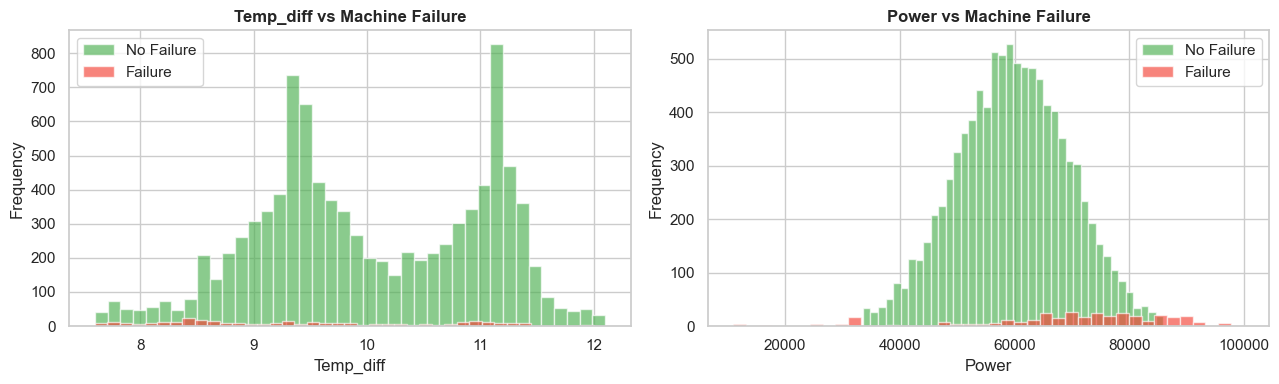

In [16]:
# Visualise engineered features vs target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['Temp_diff', 'Power']):
    for label, color in [(0, '#4CAF50'), (1, '#F44336')]:
        ax.hist(df[df['Machine failure'] == label][col], bins=40,
                alpha=0.65, color=color,
                label='No Failure' if label == 0 else 'Failure', edgecolor='white')
    ax.set_title(f'{col} vs Machine Failure', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Feature–Target Split

In [17]:
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print()
print("Features used:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Feature matrix X : (10000, 13)
Target vector  y : (10000,)

Features used:
   1. Type
   2. Air temperature [K]
   3. Process temperature [K]
   4. Rotational speed [rpm]
   5. Torque [Nm]
   6. Tool wear [min]
   7. TWF
   8. HDF
   9. PWF
  10. OSF
  11. RNF
  12. Temp_diff
  13. Power


## 7. Handle Class Imbalance — SMOTE

The dataset has a **28.5:1 class imbalance** (9,661 vs 339).  
A naive Decision Tree will learn to always predict "No Failure" and still achieve ~96% accuracy.

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic samples  
for the minority class in feature space, making the training set balanced.

> ⚠️ SMOTE is applied **only on the training set** (after splitting) to prevent data leakage.  
> The test set remains untouched and reflects the real-world distribution.


In [18]:
# Split first, then apply SMOTE only on train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(f"  Train set : {X_train.shape[0]} rows | Failure={y_train.sum()} | No Failure={len(y_train)-y_train.sum()}")
print(f"  Test  set : {X_test.shape[0]}  rows | Failure={y_test.sum()} | No Failure={len(y_test)-y_test.sum()}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print()
print("After SMOTE (train set only):")
print(f"  Train set : {X_train_sm.shape[0]} rows | Failure={y_train_sm.sum()} | No Failure={len(y_train_sm)-y_train_sm.sum()}")
print(f"  Test  set : {X_test.shape[0]}  rows (unchanged — real distribution preserved)")

Before SMOTE:
  Train set : 8000 rows | Failure=271 | No Failure=7729
  Test  set : 2000  rows | Failure=68 | No Failure=1932

After SMOTE (train set only):
  Train set : 15458 rows | Failure=7729 | No Failure=7729
  Test  set : 2000  rows (unchanged — real distribution preserved)


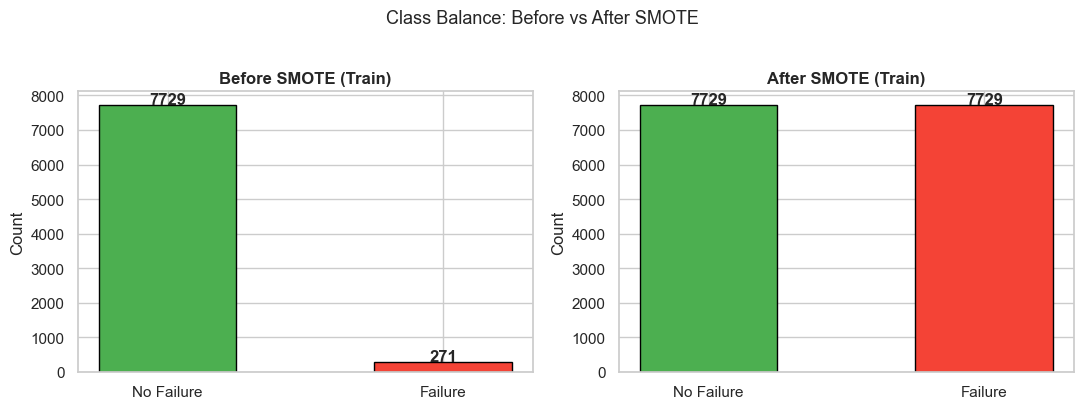

In [19]:
# Visualise class balance before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (y_data, title) in zip(axes, [
    (y_train,    'Before SMOTE (Train)'),
    (y_train_sm, 'After SMOTE (Train)')
]):
    counts = y_data.value_counts()
    ax.bar(['No Failure', 'Failure'], [counts[0], counts[1]],
           color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Train–Test Split Summary

Already performed in Step 7 with `stratify=y` to preserve class proportions.


In [20]:
print("Train-Test Split (80/20, stratified):")
print(f"  X_train (post-SMOTE) : {X_train_sm.shape}")
print(f"  X_test               : {X_test.shape}")
print(f"  y_train (post-SMOTE) : {y_train_sm.shape}")
print(f"  y_test               : {y_test.shape}")
print()
print("Test set class distribution (real-world):")
print(f"  No Failure : {(y_test == 0).sum()}")
print(f"  Failure    : {(y_test == 1).sum()}")

Train-Test Split (80/20, stratified):
  X_train (post-SMOTE) : (15458, 13)
  X_test               : (2000, 13)
  y_train (post-SMOTE) : (15458,)
  y_test               : (2000,)

Test set class distribution (real-world):
  No Failure : 1932
  Failure    : 68


## 9. Feature Scaling

Decision Trees do **not** require feature scaling (splits are threshold-based, not distance-based).  
However, scaling is included here for completeness — useful if you later compare with  
Logistic Regression, SVM, or KNN on the same preprocessed data.


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("StandardScaler applied (fit on train, transform on both).")
print()
print("Scaled X_train — first 3 rows:")
display(X_train_scaled.head(3).round(3))

StandardScaler applied (fit on train, transform on both).

Scaled X_train — first 3 rows:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Temp_diff,Power
0,1.196,0.804,0.552,-0.215,0.160,-1.048,-0.196,-0.305,-0.42,-0.315,-0.031,-0.790,0.272
1,1.196,-1.784,-1.392,-0.406,0.104,0.128,-0.196,-0.305,-0.42,-0.315,32.086,1.533,0.019
2,1.196,0.287,1.075,-0.546,0.049,0.203,-0.196,-0.305,-0.42,-0.315,-0.031,0.856,-0.182


## 10. Save Preprocessed Data

In [22]:
# Save all splits — unscaled (for DT) and scaled (for other models)
X_train_sm.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train_sm.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

# Full cleaned dataset (before split)
df.to_csv('ai4i2020_cleaned.csv', index=False)

print("Files saved:")
print("  ai4i2020_cleaned.csv   — full cleaned dataset")
print("  X_train.csv            — train features (post-SMOTE, unscaled)")
print("  X_test.csv             — test features (unscaled)")
print("  y_train.csv            — train labels (post-SMOTE)")
print("  y_test.csv             — test labels")
print("  X_train_scaled.csv     — train features (scaled)")
print("  X_test_scaled.csv      — test features (scaled)")

Files saved:
  ai4i2020_cleaned.csv   — full cleaned dataset
  X_train.csv            — train features (post-SMOTE, unscaled)
  X_test.csv             — test features (unscaled)
  y_train.csv            — train labels (post-SMOTE)
  y_test.csv             — test labels
  X_train_scaled.csv     — train features (scaled)
  X_test_scaled.csv      — test features (scaled)


## 11. Preprocessing Summary

In [23]:
print("=" * 54)
print("        PREPROCESSING SUMMARY")
print("=" * 54)
steps = [
    ("Dropped columns",        "UDI, Product ID"),
    ("Encoded column",         "Type → ordinal (L=0, M=1, H=2)"),
    ("New feature: Temp_diff", "Process temp − Air temp"),
    ("New feature: Power",     "Torque × Rotational speed"),
    ("Class imbalance fix",    "SMOTE on training set only"),
    ("Train/Test split",       "80/20, stratified"),
    ("Scaling",                "StandardScaler (optional for DT)"),
    ("Final train shape",      str(X_train_sm.shape)),
    ("Final test shape",       str(X_test.shape)),
]
for k, v in steps:
    print(f"  {k:<28}: {v}")
print("=" * 54)
print()
print("✅ Data is ready for Decision Tree modelling.")
print("→ Proceed to: 03_modelling.ipynb")

        PREPROCESSING SUMMARY
  Dropped columns             : UDI, Product ID
  Encoded column              : Type → ordinal (L=0, M=1, H=2)
  New feature: Temp_diff      : Process temp − Air temp
  New feature: Power          : Torque × Rotational speed
  Class imbalance fix         : SMOTE on training set only
  Train/Test split            : 80/20, stratified
  Scaling                     : StandardScaler (optional for DT)
  Final train shape           : (15458, 13)
  Final test shape            : (2000, 13)

✅ Data is ready for Decision Tree modelling.
→ Proceed to: 03_modelling.ipynb
